In [2]:
# The usual preamble
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Make the graphs a bit prettier, and bigger
plt.style.use('ggplot')



C:\Users\hjbec\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


We're going to use a new dataset here, to demonstrate how to deal with larger datasets. Let us look at the dataset for the Titanic passengers.

In [11]:
url = "https://raw.githubusercontent.com/pgarco/GESISPython2025/refs/heads/main/data/Titanic-Dataset.csv"
manifest = pd.read_csv(url, dtype='unicode')

Depending on your pandas version, you might see an error like "DtypeWarning: Columns (8) have mixed types". This means that it's encountered a problem reading in our data. In this case it almost certainly means that it has columns where some of the entries are strings and some are integers.

For now we're going to ignore it and hope we don't run into a problem, but in the long run we'd need to investigate this warning.

# What's even in it? (the summary)

When you print a large dataframe, it will only show you the first few rows.

In [5]:
manifest

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30,C148,C


# 2.2 Selecting columns and rows

To select a column, we index with the name of the column, like this:

In [12]:
manifest['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

To get the first 5 rows of a dataframe, we can use a slice: `df[:5]`.

This is a great way to get a sense for what kind of information is in the dataframe -- take a minute to look at the contents and get a feel for this dataset.

In [13]:
manifest[:5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,NaN,S


We can combine these to get the first 5 rows of a column:

In [14]:
manifest['Name'][:5]

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

and it doesn't matter which direction we do it in:

In [15]:
manifest[:5]['Name']

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

# 2.3 Selecting multiple columns

What if we just want to know the complaint type and the borough, but not the rest of the information? Pandas makes it really easy to select a subset of the columns: just index with list of columns you want.

In [16]:
manifest[['Name', 'Age']]

,Name,Age
0,"Braund, Mr. Owen Harris",22
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38
2,"Heikkinen, Miss. Laina",26
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35
4,"Allen, Mr. William Henry",35
...,...,...
886,"Montvila, Rev. Juozas",27
887,"Graham, Miss. Margaret Edith",19
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN
889,"Behr, Mr. Karl Howell",26


That showed us a summary, and then we can look at the first 10 rows:

In [17]:
manifest[['Name', 'Age']][:10]

,Name,Age
0,"Braund, Mr. Owen Harris",22
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38
2,"Heikkinen, Miss. Laina",26
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35
4,"Allen, Mr. William Henry",35
5,"Moran, Mr. James",NaN
6,"McCarthy, Mr. Timothy J",54
7,"Palsson, Master. Gosta Leonard",2
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27
9,"Nasser, Mrs. Nicholas (Adele Achem)",14


# 2.4 What's the most common age group?

This is a really easy question to answer! There's a `.value_counts()` method that we can use:

In [20]:
manifest['Age'].value_counts()

Age
24      30
22      27
18      26
19      25
28      25
        ..
36.5     1
55.5     1
0.92     1
23.5     1
74       1
Name: count, Length: 88, dtype: int64

If we just wanted the top 10 most common age groups, we can do this:

In [21]:
counts = manifest['Age'].value_counts()
counts[:10]

Age
24    30
22    27
18    26
19    25
28    25
30    25
21    24
25    23
36    22
29    20
Name: count, dtype: int64

But it gets better! We can plot them!

<Axes: xlabel='Age'>

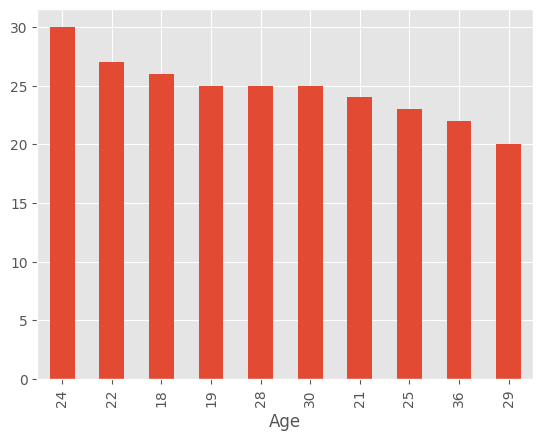

In [22]:
counts[:10].plot(kind='bar')

<style>
    @font-face {
        font-family: "Computer Modern";
        src: url('http://mirrors.ctan.org/fonts/cm-unicode/fonts/otf/cmunss.otf');
    }
    div.cell{
        width:800px;
        margin-left:16% !important;
        margin-right:auto;
    }
    h1 {
        font-family: Helvetica, serif;
    }
    h4{
        margin-top:12px;
        margin-bottom: 3px;
       }
    div.text_cell_render{
        font-family: Computer Modern, "Helvetica Neue", Arial, Helvetica, Geneva, sans-serif;
        line-height: 145%;
        font-size: 130%;
        width:800px;
        margin-left:auto;
        margin-right:auto;
    }
    .CodeMirror{
            font-family: "Source Code Pro", source-code-pro,Consolas, monospace;
    }
    .text_cell_render h5 {
        font-weight: 300;
        font-size: 22pt;
        color: #4057A1;
        font-style: italic;
        margin-bottom: .5em;
        margin-top: 0.5em;
        display: block;
    }
    
    .warning{
        color: rgb( 240, 20, 20 )
        }  